# 🎰 Bandit Strategy Comparison: ε-Greedy vs UCB vs Thompson Sampling

This notebook compares three exploration strategies for solving the multi-armed bandit problem using a custom Gymnasium-compatible environment.

In [1]:
# ✅ Install dependencies
# !pip install gymnasium matplotlib


In [2]:

import numpy as np
import random
import matplotlib.pyplot as plt
from gymnasium import Env, spaces


## 🧪 Define Custom Two-Armed Bandit Environment

In [3]:

class TwoArmedBanditEnv(Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(1)
        self.p_dist = [0.8, 0.2]  # Probabilities of reward

    def reset(self, seed=None, options=None):
        return 0, {}

    def step(self, action):
        reward = 1 if random.random() < self.p_dist[action] else 0
        return 0, reward, False, False, {}


## 🤖 Strategy 1: ε-Greedy

In [4]:

def run_epsilon_greedy(env, episodes=1000, epsilon=0.1):
    Q = np.zeros(env.action_space.n)
    N = np.zeros(env.action_space.n)
    rewards = []

    for _ in range(episodes):
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q)

        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

    return rewards


## 📈 Strategy 2: UCB

In [5]:

def run_ucb(env, episodes=1000, c=2):
    Q = np.zeros(env.action_space.n)
    N = np.zeros(env.action_space.n)
    rewards = []

    for t in range(1, episodes + 1):
        if 0 in N:
            action = np.argmin(N)
        else:
            ucb_values = Q + c * np.sqrt(np.log(t) / N)
            action = np.argmax(ucb_values)

        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

    return rewards


## 🎯 Strategy 3: Thompson Sampling

In [6]:

def run_thompson_sampling(env, episodes=1000):
    successes = np.zeros(env.action_space.n)
    failures = np.zeros(env.action_space.n)
    rewards = []

    for _ in range(episodes):
        theta = [np.random.beta(successes[a] + 1, failures[a] + 1) for a in range(env.action_space.n)]
        action = np.argmax(theta)

        _, reward, _, _, _ = env.step(action)
        rewards.append(reward)

        if reward == 1:
            successes[action] += 1
        else:
            failures[action] += 1

    return rewards


## 🧪 Run All Strategies and Compare

In [7]:

env = TwoArmedBanditEnv()
eps_rewards = run_epsilon_greedy(env, episodes=1000, epsilon=0.1)

env = TwoArmedBanditEnv()
ucb_rewards = run_ucb(env, episodes=1000, c=2)

env = TwoArmedBanditEnv()
ts_rewards = run_thompson_sampling(env, episodes=1000)


## 📊 Plot Cumulative Average Rewards

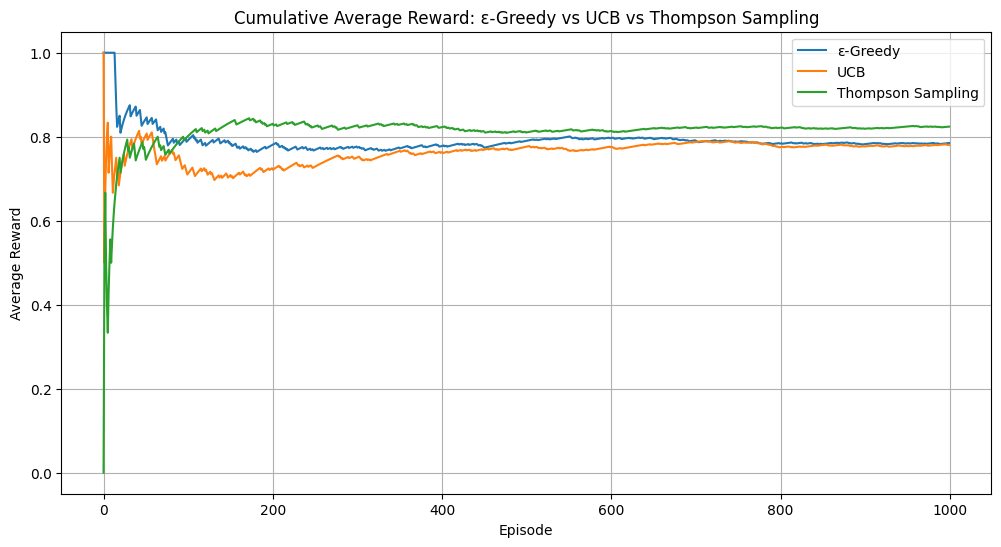

In [8]:

def plot_avg_rewards(*reward_lists, labels):
    plt.figure(figsize=(12, 6))
    for rewards, label in zip(reward_lists, labels):
        cumulative_avg = np.cumsum(rewards) / (np.arange(1, len(rewards) + 1))
        plt.plot(cumulative_avg, label=label)
    plt.title("Cumulative Average Reward: ε-Greedy vs UCB vs Thompson Sampling")
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_avg_rewards(eps_rewards, ucb_rewards, ts_rewards,
                 labels=["ε-Greedy", "UCB", "Thompson Sampling"])
